In [99]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from skimage import morphology
from scipy.stats import poisson
import scipy.stats as stats

In [100]:
sim = Simulation("Cosmics")
switchOffAllEffects(sim)
sim.outputDir = os.environ["PLATO_WORKDIR"]

# Multiple full-frame exposure

numExposures = 1000
sim["ObservingParameters/NumExposures"] = numExposures
sim["SubField/NumRows"] = 4510
sim["SubField/NumColumns"] = 4510

# With cosmics

print("With cosmics")
sim["Sky/IncludeCosmicsInSubField"] = "yes"
outputWithCosmics = sim.run(removeOutputFile = True)

# Without cosmics

print("Without cosmics")
sim["Sky/IncludeCosmicsInSubField"] = "no"
outputWithoutCosmics = sim.run(removeOutputFile = True)

With cosmics


Without cosmics




# Number of "islands"

In [102]:
numIslands1 = np.array([])
numIslands2 = np.array([])

for exposure in range(numExposures):
    
    print(exposure)
    
    diff = outputWithCosmics.getImage(exposure) - outputWithoutCosmics.getImage(exposure)
    diff[diff!=0] = 1
    
    labels, num = morphology.label(diff, connectivity=1, return_num=True)
    numIslands1 = np.append(numIslands1, num)
    
    labels, num = morphology.label(diff, connectivity=2, return_num=True)
    numIslands2 = np.append(numIslands2, num)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [191]:
print(numIslands2 / cycleTime / numPixels  / (pixelSize**2))

[11.36173202  4.89575995  8.67652969  8.67592272 14.05118309 12.27642459
 15.819265    8.65407207  7.74727002  9.57786908  9.57544123 11.39025926
 11.41150295 13.19718678 12.28128029 12.29948916  9.57119249  9.579083
  3.93797304  8.65225118  9.5936501   7.74727002  7.73027507 11.36840861
  9.61367987  7.71145923  8.64011193 13.20507729  9.59971973  5.85900952
  7.72117063  9.6033615  11.3847966  11.39329407 12.34622528  7.73088203
 10.50894963  3.93008253  9.58454567  7.74727002  8.6892759   9.58211781
  5.84262153  7.72056367 10.49923823  3.93493823 12.269748    9.5499488
  7.72784722 14.12948126  8.68745501 14.10763061 10.49316861 14.95495033
  6.81133376 12.32133981 11.39693585  8.6844202  11.40361243 13.15530636
  9.60700328  7.71267315 10.49559646 13.15712725  7.74848394  8.6698531
  6.79858755 10.52048192 12.32558855 11.40846814 14.08942173  6.79433881
 10.50166608 11.3993637  10.51380533 11.39693585 14.97801491  4.8933321
  6.77795082 10.50409393 10.4640344   6.80344325 16.6720

17584.453
15564.556
16475


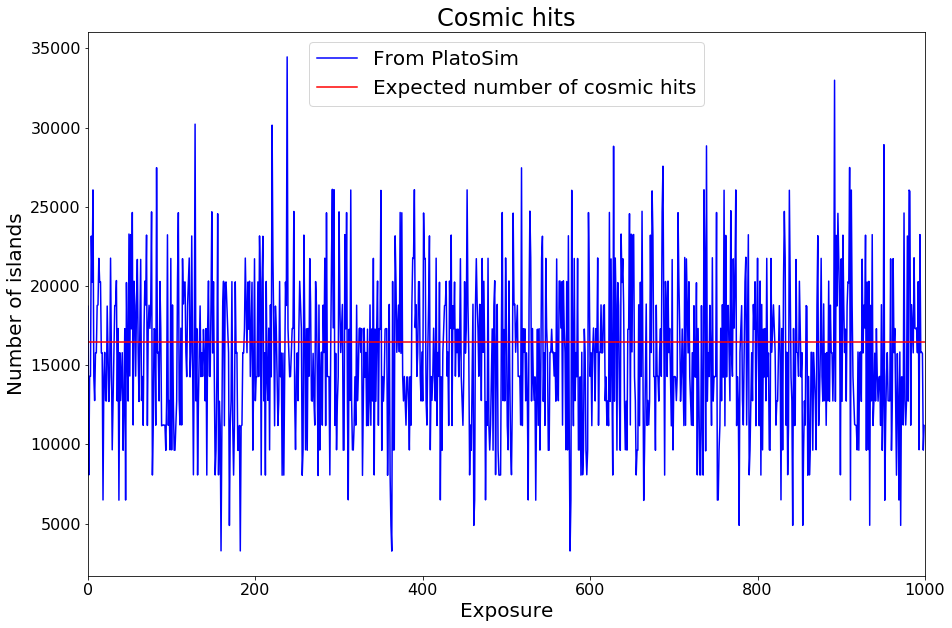

In [245]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
############### 

plt.plot(numIslands2, "b", label="From PlatoSim")
# plt.plot(numIslands1, "b--", label="Number of islands (connectivitiy = 1)")
# plt.plot(numIslands2, "b", label="Number of islands (connectivitiy = 2)")



########
# Theory
########

cosmicHitRate = sim["Sky/Cosmics/CosmicHitRate"]
cycleTime = sim["ObservingParameters/CycleTime"]
numPixels = sim["CCD/NumRows"] * sim["CCD/NumColumns"]
pixelSize = sim["CCD/PixelSize"] / 10000.0

expectedNumCosmics = cosmicHitRate * cycleTime * numPixels * pixelSize**2
plt.plot([0, numExposures], [expectedNumCosmics, expectedNumCosmics], "r", label="Expected number of cosmic hits")



########
# Layout
########

plt.title("Cosmic hits", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Exposure", fontsize = 20)
plt.ylabel("Number of islands", fontsize = 20)

plt.xlim([0, numExposures])

print(np.mean(numIslands1))
print(np.mean(numIslands2))
print(int(expectedNumCosmics))

# Cosmic hit rate

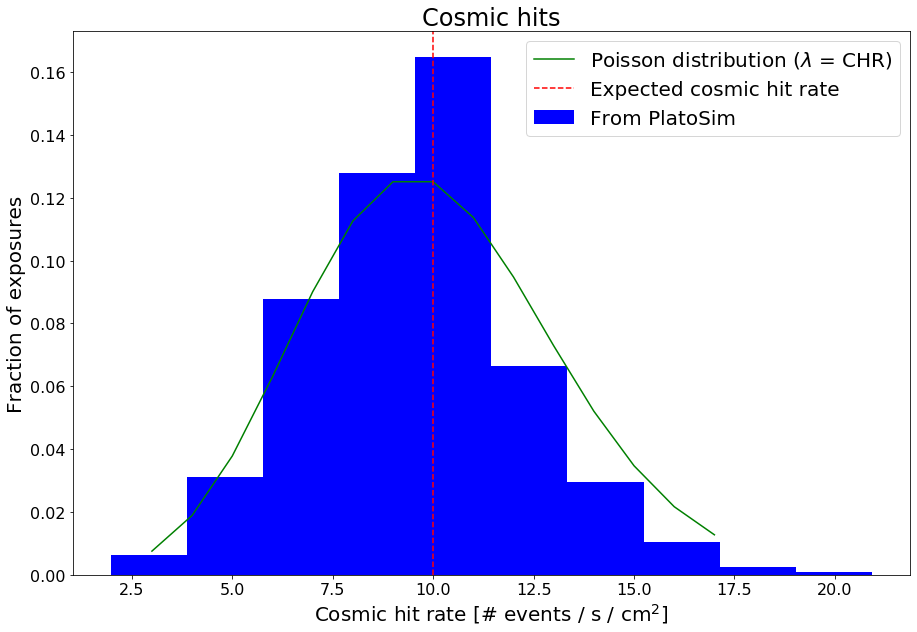

In [246]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)


###############
# From PlatoSim
###############

factor = cycleTime * numPixels * pixelSize**2
# plt.hist(numIslands1 / factor, density=True, color="b", alpha=0.5)
plt.hist(numIslands2 / factor, density=True, color="b", label="From PlatoSim")



######################
# Poisson distribution
######################

mu = cosmicHitRate
x = np.arange(poisson.ppf(0.01, mu), poisson.ppf(0.99, mu))
ax.plot(x, poisson.pmf(x, mu), "g", label="Poisson distribution ($\\lambda$ = CHR)")

plt.axvline(x = mu, color = "r", linestyle = "dashed", label = "Expected cosmic hit rate")



########
# Layout
########

plt.title("Cosmic hits", fontsize = 24)
plt.xlabel("Cosmic hit rate [# events / s / cm$^2$]", fontsize = 20)
plt.ylabel("Fraction of exposures", fontsize = 20)

plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
# plt.xlim([expectedCosmicHitRate - 10, expectedCosmicHitRate + 10])

# Trail length

In [122]:
trailLength = np.array([])

for exposure in range(numExposures):
    
    print(exposure)
    
    diff = outputWithCosmics.getImage(exposure) - outputWithoutCosmics.getImage(exposure)
    diff[diff!=0] = 1
    
    trailLength = np.append(trailLength, np.sum(diff))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

7.6496303401635055


(0, 15)

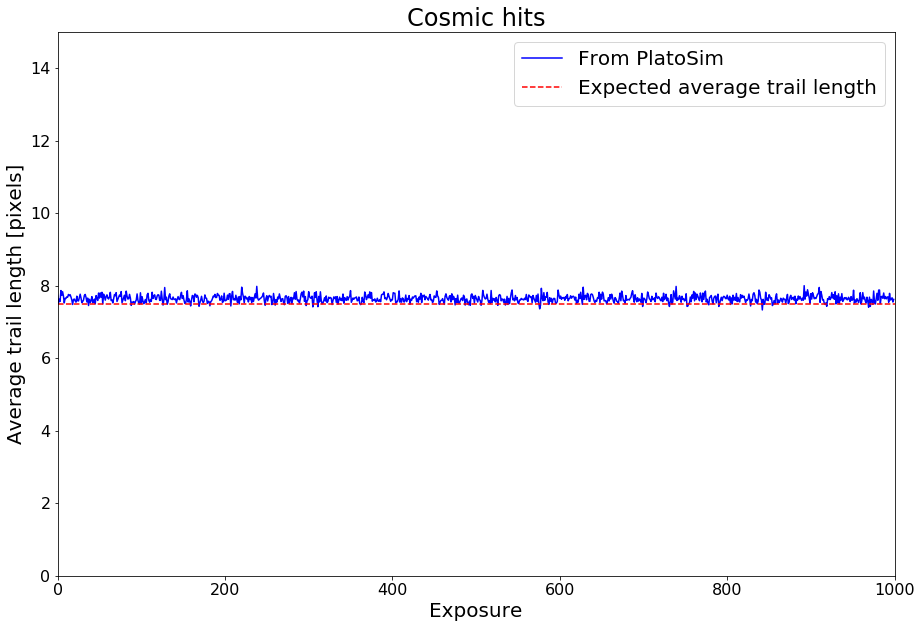

In [247]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
############### 

# plt.plot(trailLength / expectedNumCosmics, "b", label="From PlatoSim")
# plt.plot(trailLength / numIslands2, "b", label="From PlatoSim")
plt.plot(trailLength / numIslands2 / math.sqrt(2), "b", label="From PlatoSim")
print(np.mean(trailLength / numIslands2 / math.sqrt(2)))



########
# Theory
########

trailLengthInterval = sim["Sky/Cosmics/TrailLength"]

plt.axhline(y = (trailLengthInterval[0] + trailLengthInterval[1]) / 2, color = "r", linestyle = "dashed", label="Expected average trail length")



########
# Layout
########

plt.title("Cosmic hits", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Exposure", fontsize = 20)
plt.ylabel("Average trail length [pixels]", fontsize = 20)

plt.xlim([0, numExposures])
plt.ylim(trailLengthInterval)
# plt.ylim([6.5,8.5])

# Intensity

In [152]:
intensity = np.array([])

for exposure in range(numExposures):
    
    print(exposure)
    
    diff = outputWithCosmics.getImage(exposure) - outputWithoutCosmics.getImage(exposure)
    
    intensity = np.append(intensity, np.sum(diff))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

array([4.14386432e+08, 1.73116032e+08, 3.10960192e+08, 3.09501824e+08,
       5.17516896e+08, 4.49739104e+08, 5.85988928e+08, 3.12384384e+08,
       2.74877952e+08, 3.44941472e+08, 3.45165056e+08, 4.14541344e+08,
       4.16262592e+08, 4.82872448e+08, 4.49040896e+08, 4.50794560e+08,
       3.47280800e+08, 3.45112544e+08, 1.38261680e+08, 3.10033312e+08,
       3.43616704e+08, 2.76251904e+08, 2.77123360e+08, 4.14230080e+08,
       3.44654208e+08, 2.76950848e+08, 3.11230304e+08, 4.83742944e+08,
       3.45853056e+08, 2.06753360e+08, 2.76110336e+08, 3.45293856e+08,
       4.13878528e+08, 4.14558368e+08, 4.48716064e+08, 2.79270752e+08,
       3.80297408e+08, 1.37638032e+08, 3.45206400e+08, 2.77586784e+08,
       3.10894048e+08, 3.45123200e+08, 2.07389328e+08, 2.77199584e+08,
       3.80568960e+08, 1.39181824e+08, 4.49999776e+08, 3.47111648e+08,
       2.77628832e+08, 5.21262240e+08, 3.11620544e+08, 5.17871200e+08,
       3.79251264e+08, 5.54625472e+08, 2.40233344e+08, 4.48832000e+08,
      

21891.29845324953


(2000, 40000)

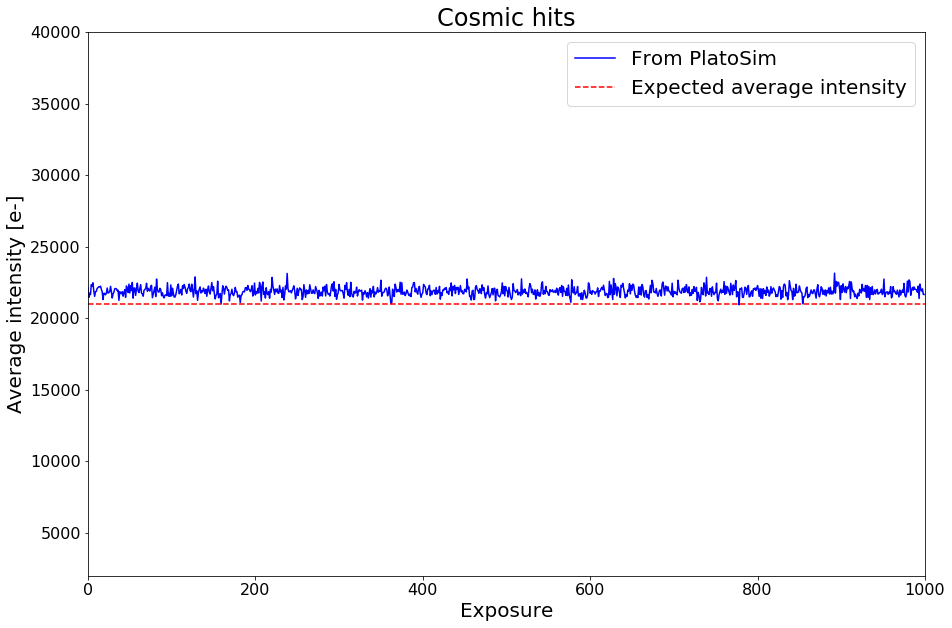

In [249]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
############### 

plt.plot(intensity / numIslands2, "b", label="From PlatoSim")
print(np.mean(intensity / numIslands2))



########
# Theory
########

intensityInterval = sim["Sky/Cosmics/Intensity"]

plt.axhline(y = (intensityInterval[0] + intensityInterval[1]) / 2, color = "r", linestyle = "dashed", label="Expected average intensity")
# plt.axhline(y = intensityInterval[0], color = "r", linestyle = "dashed")
# plt.axhline(y = intensityInterval[1], color = "r", linestyle = "dashed")



########
# Layout
########

plt.title("Cosmic hits", fontsize = 24)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Exposure", fontsize = 20)
plt.ylabel("Average intensity [e-]", fontsize = 20)

plt.xlim([0, numExposures])
plt.ylim(intensityInterval)

# Entry position

In [250]:
diff = outputWithCosmics.getImage(0) - outputWithoutCosmics.getImage(0)
diff[diff!=0] = 1

In [251]:
positions = np.where(diff == 1)

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

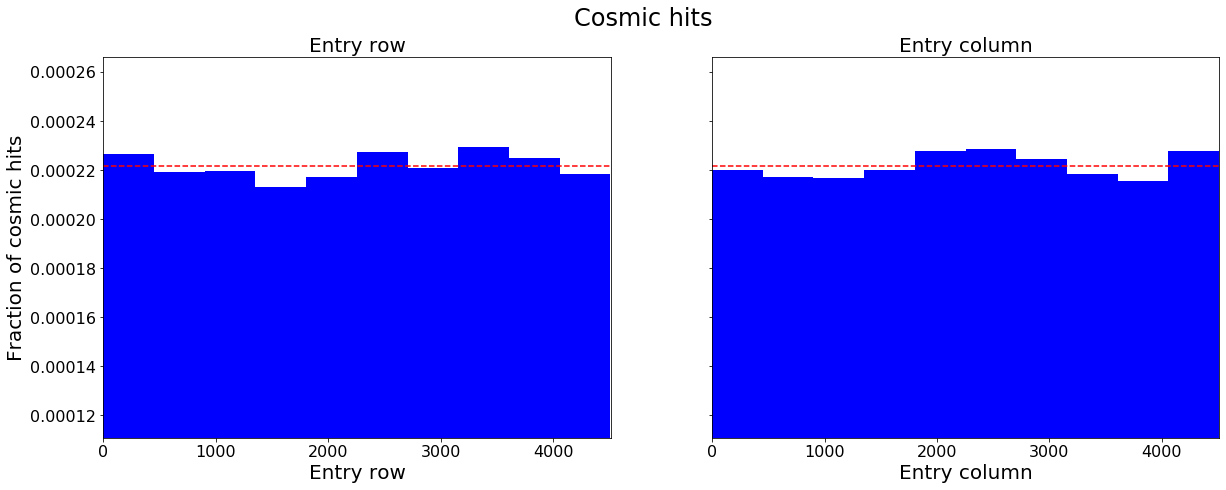

In [255]:
fig = plt.figure(figsize = (20, 7))
fig.suptitle("Cosmic hits", fontsize=24)
plt.tight_layout()


###########
# Entry row
###########

ax1 = fig.add_subplot(1, 2, 1)

numRows = sim["CCD/NumRows"]
plt.hist(positions[0], density=True, color="b", label="From PlatoSim")

plt.axhline(y = 1 / numRows, color = "r", linestyle = "dashed", label="Expected average trail length")

for tick in ax1.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax1.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Entry row", fontsize = 20)
plt.ylabel("Fraction of cosmic hits", fontsize = 20)

plt.xlim([0, numRows])
plt.ylim([1 / numRows / 2, 1.2 / numRows])

plt.title("Entry row", fontsize=20)



##############
# Entry column
##############

ax2 = fig.add_subplot(1, 2, 2, sharey=ax1)

numColumns = sim["CCD/NumColumns"]
plt.hist(positions[1], density=True, color="b", label="From PlatoSim")

plt.axhline(y = 1 / 4510, color = "r", linestyle = "dashed", label="Expected average trail length")

for tick in ax2.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Entry column", fontsize = 20)

plt.xlim([0, numColumns])

plt.title("Entry column", fontsize=20)

plt.setp(ax2.get_yticklabels(), visible=False)

# Visualisation of the cosmic hits

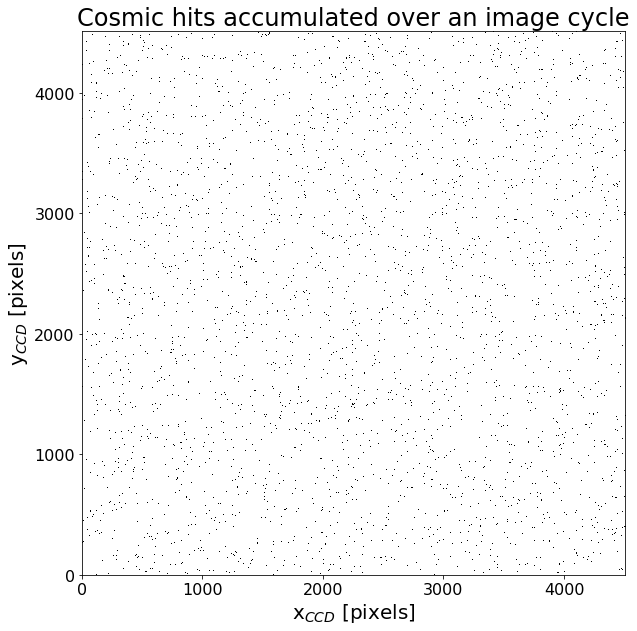

In [178]:
fig = plt.figure(figsize = (15, 10))
ax = fig.add_subplot(1, 1, 1)

im = plt.imshow(diff, origin='lower', cmap='Greys')



########
# Layout
########

plt.title("Cosmic hits accumulated over an image cycle", fontsize = 24)
plt.xlabel("x$_{CCD}$ [pixels]", fontsize = 20)
plt.ylabel("y$_{CCD}$ [pixels]", fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)